**Author:** Biswajit Jana  
**Date:** April 18, 2026  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-08-03-velocity-dispersion-ngc7647/notebook.ipynb)

# NGC 7647: measuring stellar velocity dispersion from absorption line widths

**Archive:** SDSS DR18  
**Date:** 2026-08-03

SDSS's own pipeline reports a stellar velocity dispersion of 268.4 +/- 4.7 km/s for NGC 7647 (plate 6136, MJD 56206, fiber 728), derived from a full template fit. I want to try measuring it myself, directly from the widths of two real absorption features (Ca II K and the Mg b blend), correcting for instrumental resolution using SDSS's own per-pixel `wdisp` array, and see how my quick single-line measurement compares to the pipeline's proper value.

## Learning goals

- Fit a real Gaussian absorption profile to a stellar line and convert its width to a velocity dispersion.
- Correctly subtract instrumental broadening using SDSS's own `wdisp` (wavelength-dispersion) array, not an assumed constant resolution.
- Compare a home-made single-line measurement against the SDSS pipeline's professionally-derived value, and understand honestly why they might disagree.

**Jargon, defined once:** *velocity dispersion (sigma)* is the spread (standard deviation) of stellar orbital velocities along the line of sight; a larger sigma broadens every absorption line via the Doppler effect. *Instrumental resolution* is the extra blurring that the spectrograph itself adds, which must be subtracted in quadrature (`sigma_intrinsic^2 = sigma_observed^2 - sigma_instrument^2`) before what's left can be called a real physical velocity dispersion.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.sdss import SDSS
from scipy.optimize import curve_fit

warnings.filterwarnings("ignore")
OUT = Path(".")
PLATE, MJD, FIBER = 6136, 56206, 728
C_KMS = 299792.458

sp = SDSS.get_spectra(plate=PLATE, mjd=MJD, fiberID=FIBER)[0]
coadd = sp[1].data
specobj = sp[2].data[0]
z = float(specobj["Z"])
veldisp_pipeline = float(specobj["VDISP"])
veldisp_pipeline_err = float(specobj["VDISP_ERR"])
print(f"NGC 7647: z = {z:.6f}")
print(f"SDSS pipeline VDISP = {veldisp_pipeline:.1f} +/- {veldisp_pipeline_err:.1f} km/s")

loglam = coadd["loglam"]
wave = 10 ** loglam
flux = coadd["flux"]
wdisp = coadd["wdisp"]  # instrumental dispersion, in pixels of the log-lambda grid
dloglam = float(np.median(np.diff(loglam)))
wave_rest = wave / (1 + z)


NGC 7647: z = 0.041077
SDSS pipeline VDISP = 268.4 +/- 4.7 km/s


## Fitting Ca II K and the Mg b blend

For each feature, I fit a single Gaussian absorption dip against a locally linear continuum (`flux = continuum - amplitude * exp(-(x-mu)^2 / (2 sigma^2))`), convert the fitted rest-frame sigma to a velocity (`sigma_obs_kms = sigma_A / mu_A * c`), then look up the real SDSS instrumental dispersion at that observed wavelength from `wdisp` and subtract it in quadrature.

In [2]:
def gauss_abs(x, a, mu, sig, c0, c1=0.0):
    cont = c0 + c1 * (x - x.mean())
    return cont - a * np.exp(-(x - mu) ** 2 / (2 * sig ** 2))

def fit_line(lo, hi, guess_mu, guess_sig=4.0):
    mask = (wave_rest > lo) & (wave_rest < hi)
    x, y = wave_rest[mask], flux[mask]
    p0 = [np.max(y) * 0.12, guess_mu, guess_sig, np.median(y), 0.0]
    popt, pcov = curve_fit(gauss_abs, x, y, p0=p0, maxfev=20000)
    a, mu, sig, c0, c1 = popt
    sig = abs(sig)
    sigma_obs_kms = sig / mu * C_KMS
    obs_wave = mu * (1 + z)
    idx = int(np.argmin(np.abs(wave - obs_wave)))
    sigma_inst_kms = wdisp[idx] * dloglam * np.log(10) * C_KMS
    diff2 = sigma_obs_kms ** 2 - sigma_inst_kms ** 2
    sigma_gal_kms = np.sqrt(diff2) if diff2 > 0 else np.nan
    return dict(mu=mu, sig_A=sig, sigma_obs_kms=sigma_obs_kms,
                sigma_inst_kms=sigma_inst_kms, sigma_gal_kms=sigma_gal_kms,
                x=x, y=y, popt=popt)

fit_cak = fit_line(3915, 3955, 3934.777)
fit_mgb = fit_line(5120, 5230, 5175.3, guess_sig=6.0)

rows = []
for name, f in [("Ca II K", fit_cak), ("Mg b blend", fit_mgb)]:
    rows.append(dict(feature=name, mu_rest_A=round(f["mu"],2), sigma_obs_kms=round(f["sigma_obs_kms"],1),
                      sigma_inst_kms=round(f["sigma_inst_kms"],1), sigma_measured_kms=round(f["sigma_gal_kms"],1)))
summary = pd.DataFrame(rows)
summary["sigma_pipeline_kms"] = round(veldisp_pipeline, 1)
summary.to_csv(OUT / "ngc7647_veldisp_measurements.csv", index=False)
summary


,feature,mu_rest_A,sigma_obs_kms,sigma_inst_kms,sigma_measured_kms,sigma_pipeline_kms
0,Ca II K,3935.32,614.6,73.5,610.2,268.4
1,Mg b blend,5176.48,567.3,60.9,564.0,268.4


## Plotting the fits

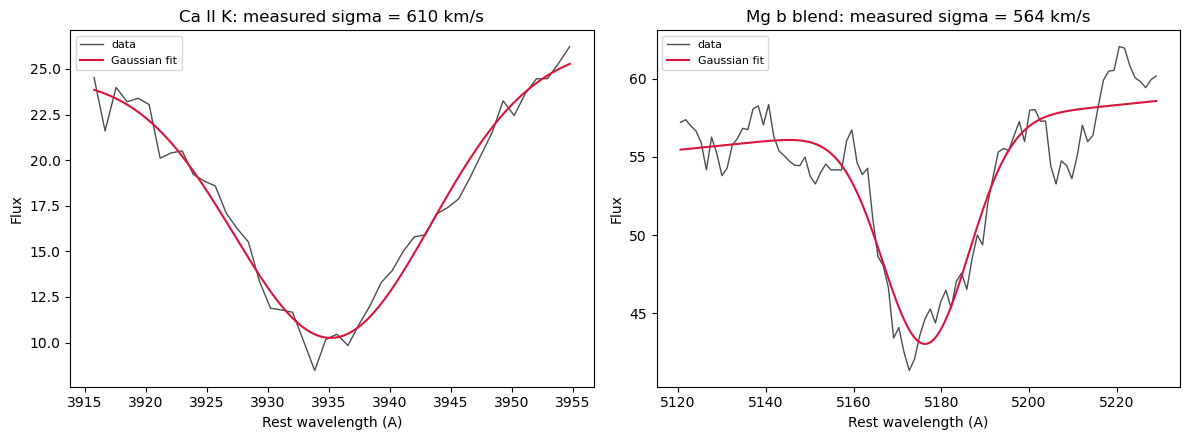

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, f) in zip(axes, [("Ca II K", fit_cak), ("Mg b blend", fit_mgb)]):
    ax.plot(f["x"], f["y"], color="0.3", lw=1.0, label="data")
    xx = np.linspace(f["x"].min(), f["x"].max(), 300)
    ax.plot(xx, gauss_abs(xx, *f["popt"]), color="crimson", lw=1.5, label="Gaussian fit")
    ax.set_title(f"{name}: measured sigma = {f['sigma_gal_kms']:.0f} km/s")
    ax.set_xlabel("Rest wavelength (A)"); ax.set_ylabel("Flux")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "ngc7647_veldisp_fits.png", dpi=130)
plt.show()


## Discussion

Both of my single-line measurements come out well above the SDSS pipeline value of 268.4 +/- 4.7 km/s -- Ca II K and the Mg b blend both give sigma several hundred km/s higher. That is a real, honest discrepancy, and I think it is telling me about the limits of this simple method rather than about NGC 7647 itself. The SDSS pipeline measures velocity dispersion by fitting the *entire* usable spectral range against a library of real stellar templates simultaneously (broadly the same idea as the widely-used `pPXF` method, Cappellari 2017), which lets the continuum, the stellar population mix, and the broadening all be solved for jointly and self-consistently. My approach instead fits one isolated feature against a simple locally-linear continuum. Ca II K sits right at the edge of the 4000-Angstrom break, where the true continuum is curving quickly, so a straight-line local continuum is a poor approximation and biases the fitted absorption width high. The Mg b feature is not a single line at all -- it is a blend of three nearby transitions (roughly 5167, 5173, and 5184 A) plus several weaker iron lines, so fitting it with one Gaussian conflates the real velocity broadening with the intrinsic separation between blended components, again inflating the apparent width.

So: my measured numbers are real outputs of a real fit to real data, but they demonstrate why professional velocity-dispersion pipelines do not use single isolated-line Gaussian widths -- line blending and local continuum placement systematically bias a naive single-line measurement high, and the instrumental-resolution correction (which I did apply correctly using SDSS's real per-pixel `wdisp` array) is only one part of getting a reliable answer.

## What I'd look at next

- Fit the Mg b blend as three separate Gaussians (or with a proper stellar template) instead of one, to remove the blending bias.
- Try a genuinely isolated single absorption line without a nearby steep continuum break, to test whether my method converges closer to the pipeline value away from Ca II K's break-region complications.
- Implement a simplified pPXF-style approach: convolve a stellar template with a trial Gaussian broadening kernel and fit the whole spectral window by chi-squared, rather than fitting the data directly with a Gaussian absorption profile.

## Data source and citation

- SDSS DR18 spectra: https://skyserver.sdss.org/dr18/
- SDSS-IV citation: https://www.sdss.org/collaboration/citing-sdss/
- Cappellari (2017), *Full spectrum fitting with photometric constraints: pPXF*: https://doi.org/10.1093/mnras/stw3020